# Análisis Exploratorio de Datos (EDA)
## Dataset: Brain Tumor MRI Classification

**Clases:** `glioma` · `meningioma` · `notumor` · `pituitary`  
**Objetivo:** Entender la distribución, características visuales y estadísticas de píxeles del dataset antes de entrenar cualquier modelo.

---
**Índice de secciones:**
1. Configuración e imports
2. Distribución de clases y balance
3. Análisis de tamaños y modos de imagen
4. Visualización de muestras por clase
5. Histogramas de intensidad de píxel
6. Estadísticas de píxel por canal y clase (media/std)
7. Mapa de calor de correlación entre clases
8. Preview de data augmentation
9. Resumen y conclusiones

## 1. Montar Drive y configuración global

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import cv2
from PIL import Image
from collections import defaultdict
from tqdm.notebook import tqdm

# Rutas
#BASE_PATH = '/content/drive/MyDrive/TRABAJO_NO_ESTRUCTURADOS/Trabajo_no_estructurados_imagen/data'
BASE_PATH = '/content/drive/MyDrive/Trabajo_no_estructurados_imagen/data'
TRAIN_DIR = os.path.join(BASE_PATH, 'Training')
TEST_DIR  = os.path.join(BASE_PATH, 'Testing')

# Configuración visual
CLASES   = sorted(os.listdir(TRAIN_DIR))           # ['glioma', 'meningioma', 'notumor', 'pituitary']
PALETTE  = {'glioma': '#4C72B0', 'meningioma': '#DD8452',
             'notumor': '#55A868', 'pituitary': '#C44E52'}
COLORES  = [PALETTE[c] for c in CLASES]

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})

random.seed(42)
np.random.seed(42)

print('Clases:', CLASES)
print('Paleta:', PALETTE)

Clases: ['glioma', 'meningioma', 'notumor', 'pituitary']
Paleta: {'glioma': '#4C72B0', 'meningioma': '#DD8452', 'notumor': '#55A868', 'pituitary': '#C44E52'}


## 2. Distribución de clases y balance

In [11]:
# Conteo de imágenes
counts = {}
for split, path in [('train', TRAIN_DIR), ('test', TEST_DIR)]:
    counts[split] = {c: len(os.listdir(os.path.join(path, c))) for c in CLASES}

total_train = sum(counts['train'].values())
total_test  = sum(counts['test'].values())

print(f"{'Clase':<15} {'Train':>8} {'%Train':>8}   {'Test':>8} {'%Test':>8}")
print('─' * 56)
for c in CLASES:
    print(f"{c:<15} {counts['train'][c]:>8}  ({counts['train'][c]/total_train*100:4.1f}%)"
          f"   {counts['test'][c]:>8}  ({counts['test'][c]/total_test*100:4.1f}%)")
print('─' * 56)
print(f"{'TOTAL':<15} {total_train:>8}             {total_test:>8}")

Clase              Train   %Train       Test    %Test
────────────────────────────────────────────────────────
glioma              1400  (25.0%)        400  (25.0%)
meningioma          1400  (25.0%)        400  (25.0%)
notumor             1400  (25.0%)        400  (25.0%)
pituitary           1400  (25.0%)        400  (25.0%)
────────────────────────────────────────────────────────
TOTAL               5600                 1600


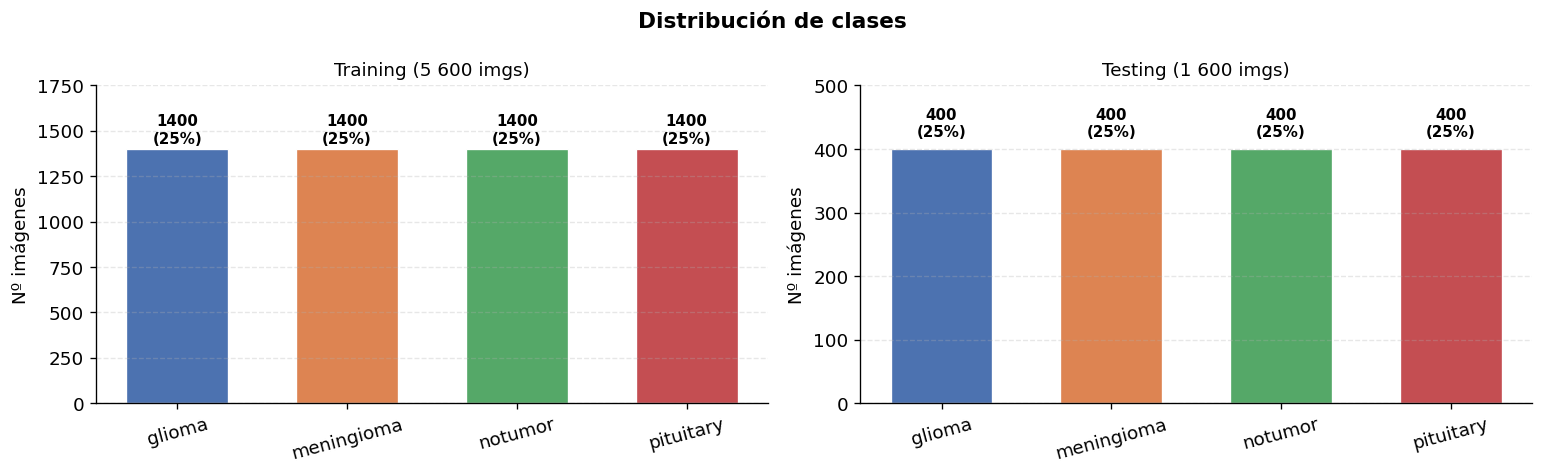

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Distribución de clases', fontsize=13, fontweight='bold')

for ax, (split, titulo) in zip(axes, [('train', 'Training (5 600 imgs)'), ('test', 'Testing (1 600 imgs)')]):
    vals = list(counts[split].values())
    bars = ax.bar(CLASES, vals, color=COLORES, edgecolor='white', linewidth=0.8, width=0.6)
    ax.set_title(titulo, fontsize=11)
    ax.set_ylabel('Nº imágenes')
    ax.set_ylim(0, max(vals) * 1.25)
    ax.tick_params(axis='x', rotation=15)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                f'{v}\n({v/(total_train if split=="train" else total_test)*100:.0f}%)',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_01_distribucion_clases.png', dpi=150, bbox_inches='tight')
plt.show()

El dataset está perfectamente balanceado por construcción (misma cantidad
de imágenes por clase). Esto es ideal para el entrenamiento ya que el modelo
no estará sesgado hacia ninguna clase y podemos usar accuracy como métrica
principal sin necesidad de class_weight ni oversampling.

En un caso real clínico esto no ocurriría: los tumores de tipo glioma son
más frecuentes que los meningiomas, por lo que un dataset real estaría
desbalanceado y requeriría técnicas adicionales.

## 3. Análisis de tamaños y modos de imagen

In [8]:
# ── Recopilar tamaños y modos (muestra de 100 imgs por clase) ──────
size_data = defaultdict(list)   # {clase: [(w, h), ...]}
mode_data = defaultdict(set)    # {clase: {modos}}

SAMPLE_N = 100   # imágenes a muestrear por clase para el análisis de tamaños

for clase in tqdm(CLASES, desc='Analizando tamaños'):
    folder = os.path.join(TRAIN_DIR, clase)
    files  = os.listdir(folder)
    sample = random.sample(files, min(SAMPLE_N, len(files)))
    for fname in sample:
        try:
            img = Image.open(os.path.join(folder, fname))
            size_data[clase].append(img.size)   # (ancho, alto)
            mode_data[clase].add(img.mode)
        except Exception:
            pass

print(f"\n{'Clase':<15} {'Min W':>7} {'Max W':>7} {'Min H':>7} {'Max H':>7} {'Modos':<20}")
print('─' * 64)
for c in CLASES:
    ws = [s[0] for s in size_data[c]]
    hs = [s[1] for s in size_data[c]]
    print(f"{c:<15} {min(ws):>7} {max(ws):>7} {min(hs):>7} {max(hs):>7} {str(mode_data[c]):<20}")

Analizando tamaños:   0%|          | 0/4 [00:00<?, ?it/s]


Clase             Min W   Max W   Min H   Max H Modos               
────────────────────────────────────────────────────────────────
glioma              512     512     512     512 {'RGB', 'L'}        
meningioma          200     534     212     674 {'RGB', 'L'}        
notumor             150    1024     168    1024 {'RGB', 'L'}        
pituitary           225    1168     225    1178 {'RGB', 'L'}        


Las imágenes presentan modos mixtos (L y RGB) según la clase, por lo que se aplicará `.convert('RGB')` en el preprocesado para garantizar 3 canales uniformes en todas las imágenes.

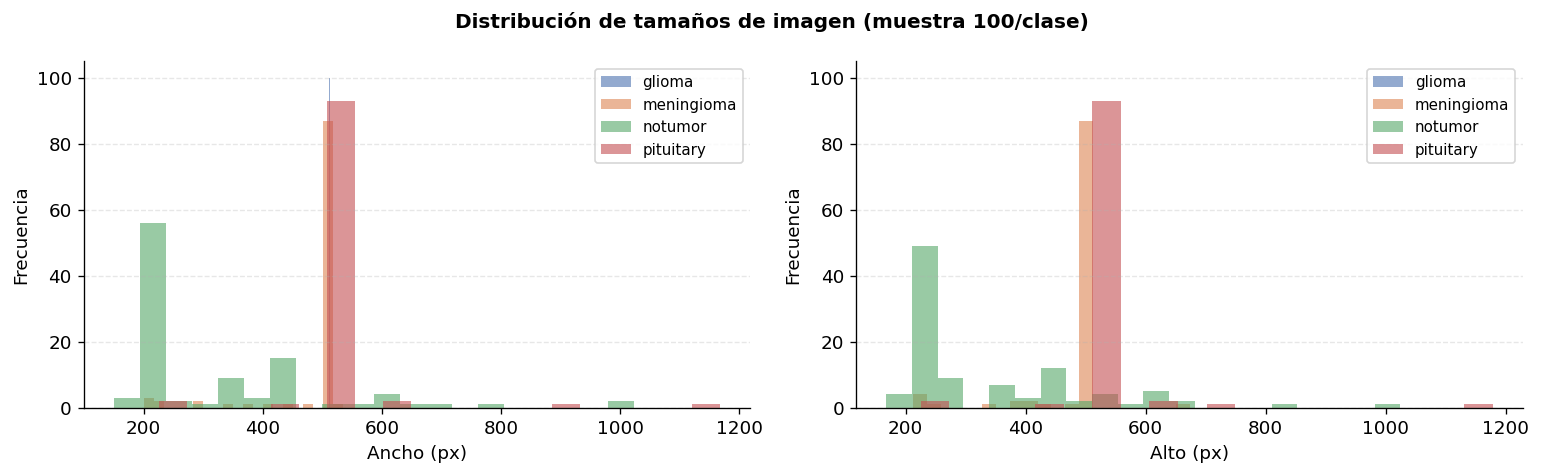

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Distribución de tamaños de imagen (muestra 100/clase)', fontsize=12, fontweight='bold')

for ax, dim, label in zip(axes, [0, 1], ['Ancho (px)', 'Alto (px)']):
    for c, col in zip(CLASES, COLORES):
        vals = [s[dim] for s in size_data[c]]
        ax.hist(vals, bins=20, alpha=0.6, color=col, label=c, edgecolor='none')
    ax.set_xlabel(label)
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('eda_02_tamanos.png', dpi=150, bbox_inches='tight')
plt.show()

Conclusión tamaños:
- Glioma, meningioma y pituitary: todas 512x512, muy consistentes.
- Notumor: más variabilidad (201-1280px), imágenes de distintas fuentes.
- En todos los casos se hará resize a 224x224 antes de entrenar,
  que es el tamaño estándar para transfer learning con VGG16/ResNet.
  Para el modelo from scratch también usaremos 224x224 por consistencia.

## 4. Visualización de muestras por clase
Ver cómo se ve cada tipo de tumor/tejido sano a simple vista.

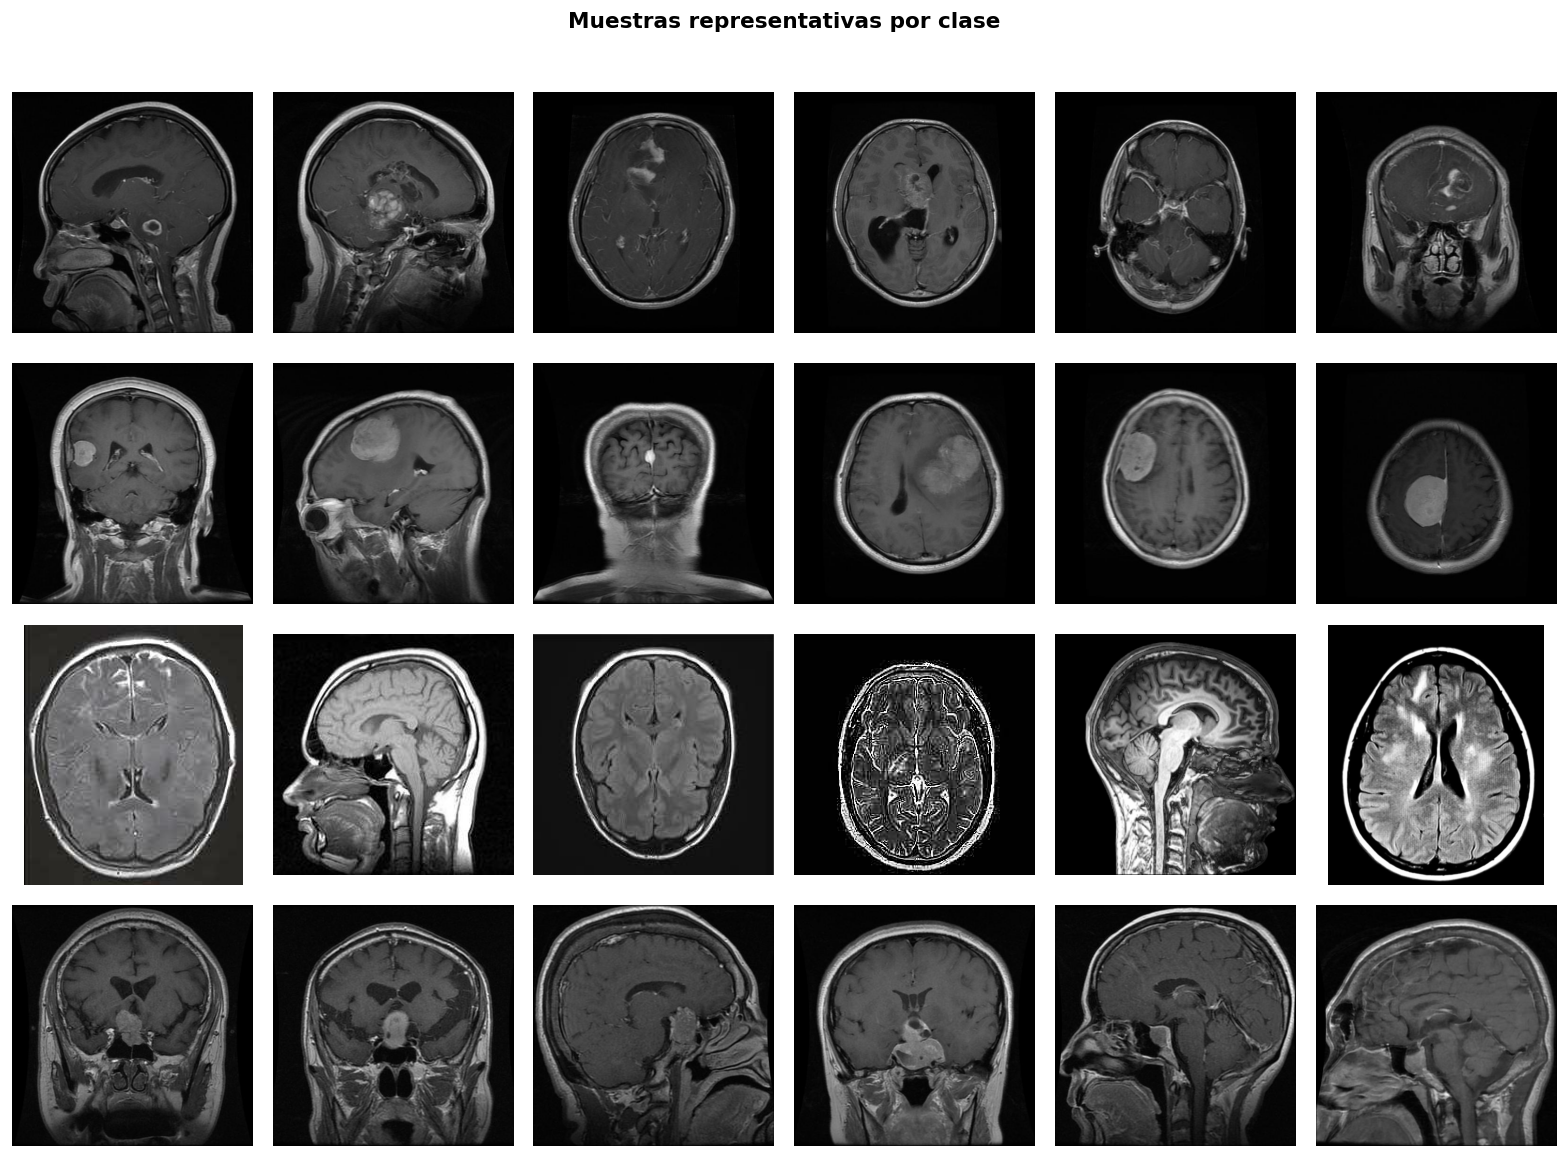

In [ ]:
N_COLS = 6   # imágenes por clase a mostrar

fig, axes = plt.subplots(len(CLASES), N_COLS, figsize=(N_COLS * 2.2, len(CLASES) * 2.4))
fig.suptitle('Muestras representativas por clase', fontsize=13, fontweight='bold', y=1.01)

for row, clase in enumerate(CLASES):
    folder = os.path.join(TRAIN_DIR, clase)
    files  = random.sample(os.listdir(folder), N_COLS)
    for col, fname in enumerate(files):
        img = Image.open(os.path.join(folder, fname)).convert('RGB')
        ax = axes[row][col]
        ax.imshow(img, cmap='gray')
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(clase, fontsize=11, fontweight='bold',
                          color=PALETTE[clase], rotation=90, labelpad=6)
            ax.yaxis.set_label_position('left')
            ax.tick_params(left=False)

plt.tight_layout()
plt.savefig('eda_03_muestras_por_clase.png', dpi=150, bbox_inches='tight')
plt.show()

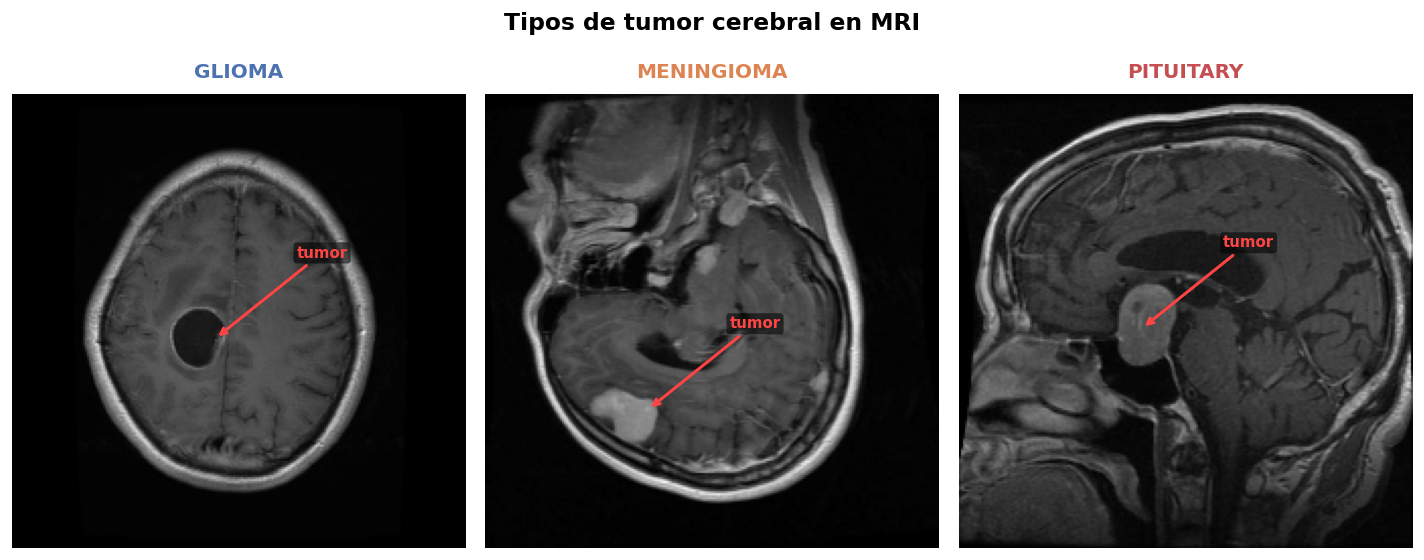

In [5]:
# Tres tipos de tumor

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
import os

tipos_tumor = ['glioma', 'meningioma', 'pituitary']

imagenes_fijas = {
    'glioma'    : 'Tr-gl_1004.jpg',
    'meningioma': 'Tr-aug-me_16.jpg',
    'pituitary' : 'Tr-pi_1001.jpg',
}

descripciones = {
    'glioma'    : 'Tumor del tejido glial',
    'meningioma': 'Tumor de las meninges',
    'pituitary' : 'Tumor de la glándula pituitaria',
}

coordenadas = {
    'glioma'    : (100, 120, 28),
    'meningioma': (80, 155, 25),
    'pituitary' : (90, 115, 22),
}

COLORES = {
    'glioma'    : '#4C72B0',
    'meningioma': '#DD8452',
    'pituitary' : '#C44E52',
}

fig, axes = plt.subplots(1, 3, figsize=(12, 5))
fig.suptitle('Tipos de tumor cerebral en MRI', fontsize=14, fontweight='bold')

for ax, clase in zip(axes, tipos_tumor):
    ruta = os.path.join(TRAIN_DIR, clase, imagenes_fijas[clase])
    img  = cv2.imread(ruta)
    img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img  = cv2.resize(img, (224, 224))
    ax.imshow(img)
    ax.axis('off')

    ax.set_title(clase.upper(), fontsize=12, fontweight='bold',
                 color=COLORES[clase], pad=10)
    ax.set_xlabel(descripciones[clase], fontsize=9, color='gray')

    # Marco de color
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(COLORES[clase])
        spine.set_linewidth(3)

    # Flecha señalando el tumor
    cx, cy, radio = coordenadas[clase]
    ax.annotate(
        'tumor',
        xy=(cx, cy),
        xytext=(cx + 40, cy - 40),
        fontsize=9, fontweight='bold', color='#ff4444',
        arrowprops=dict(arrowstyle='->', color='#ff4444', lw=1.8),
        bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.55, ec='none')
    )

plt.tight_layout()
plt.savefig('eda_tipos_tumor.png', dpi=150, bbox_inches='tight')
plt.show()

> **Nota:** Las imágenes seleccionadas son casos especialmente claros del dataset,
> elegidos intencionadamente para ilustrar cada tipo de tumor. En la práctica clínica
> real, las MRI son frecuentemente más ambiguas y difíciles de interpretar a simple
> vista, lo que justifica el uso de modelos de Deep Learning para su clasificación.


### Tipos de tumor cerebral

**Glioma** *(imagen izquierda)*  
Tumor que se origina en las células gliales, el tejido de soporte de las neuronas.
Es el tipo más frecuente y más agresivo de los tres. Crece infiltrándose dentro del
propio tejido cerebral, lo que lo hace difícil de extirpar completamente. En la MRI
se aprecia como una **masa oscura y bien delimitada**, en este caso situada en el
hemisferio derecho. Su localización puede variar, pero es frecuente encontrarlo en
los lóbulos frontal y temporal.

**Meningioma** *(imagen central)*  
Tumor que se desarrolla en las meninges, las membranas que envuelven el cerebro
por fuera. Al no crecer dentro del tejido cerebral sino sobre él, suele ser más
fácil de extirpar y generalmente tiene mejor pronóstico. En la MRI se identifica
como una **masa blanca brillante y homogénea**, pegada al borde inferior del
cerebro, bien visible en esta imagen. Es más frecuente en mujeres y suele aparecer
en la base del cráneo o en la convexidad cerebral.

**Pituitary** *(imagen derecha)*  
Tumor de la glándula pituitaria o hipófisis, situada en la base central del cerebro.
Esta glándula regula el sistema hormonal del cuerpo entero (crecimiento, tiroides,
reproducción), por lo que aunque el tumor suele ser benigno, causa importantes
alteraciones hormonales. En la MRI aparece como una **masa redondeada y brillante
en la silla turca**, la cavidad ósea donde se aloja la hipófisis, claramente visible
en la zona central-inferior de esta imagen sagital.

> **Conclusión EDA:** La variabilidad visual entre clases es notable — cada tipo
> de tumor presenta características morfológicas y de localización distintas.
> Sin embargo, dentro de cada clase también existe alta variabilidad (distintas
> orientaciones, tamaños y contrastes de MRI), lo que hace que la clasificación
> automática mediante Deep Learning sea necesaria y justificada frente a una
> inspección visual manual.

## 5. Histogramas de intensidad de píxel por clase
Analizar la distribución de brillo/contraste para cada clase. Imágenes de MRI son escala de grises — usamos el canal L (luminancia).

In [15]:
# ── Acumular histogramas (muestra de 200 imgs por clase) ───────────
SAMPLE_HIST = 200
TARGET_SIZE = (224, 224)

pixel_vals = defaultdict(list)  # {clase: array de píxeles aplanados}

for clase in tqdm(CLASES, desc='Calculando histogramas'):
    folder = os.path.join(TRAIN_DIR, clase)
    files  = random.sample(os.listdir(folder), min(SAMPLE_HIST, len(os.listdir(folder))))
    for fname in files:
        try:
            img = Image.open(os.path.join(folder, fname)).convert('L').resize(TARGET_SIZE)
            pixel_vals[clase].extend(np.array(img).flatten().tolist())
        except Exception:
            pass

print('Píxeles recopilados por clase:')
for c in CLASES:
    print(f'  {c}: {len(pixel_vals[c]):,} píxeles')

Calculando histogramas:   0%|          | 0/4 [00:00<?, ?it/s]

Píxeles recopilados por clase:
  glioma: 10,035,200 píxeles
  meningioma: 10,035,200 píxeles
  notumor: 10,035,200 píxeles
  pituitary: 10,035,200 píxeles


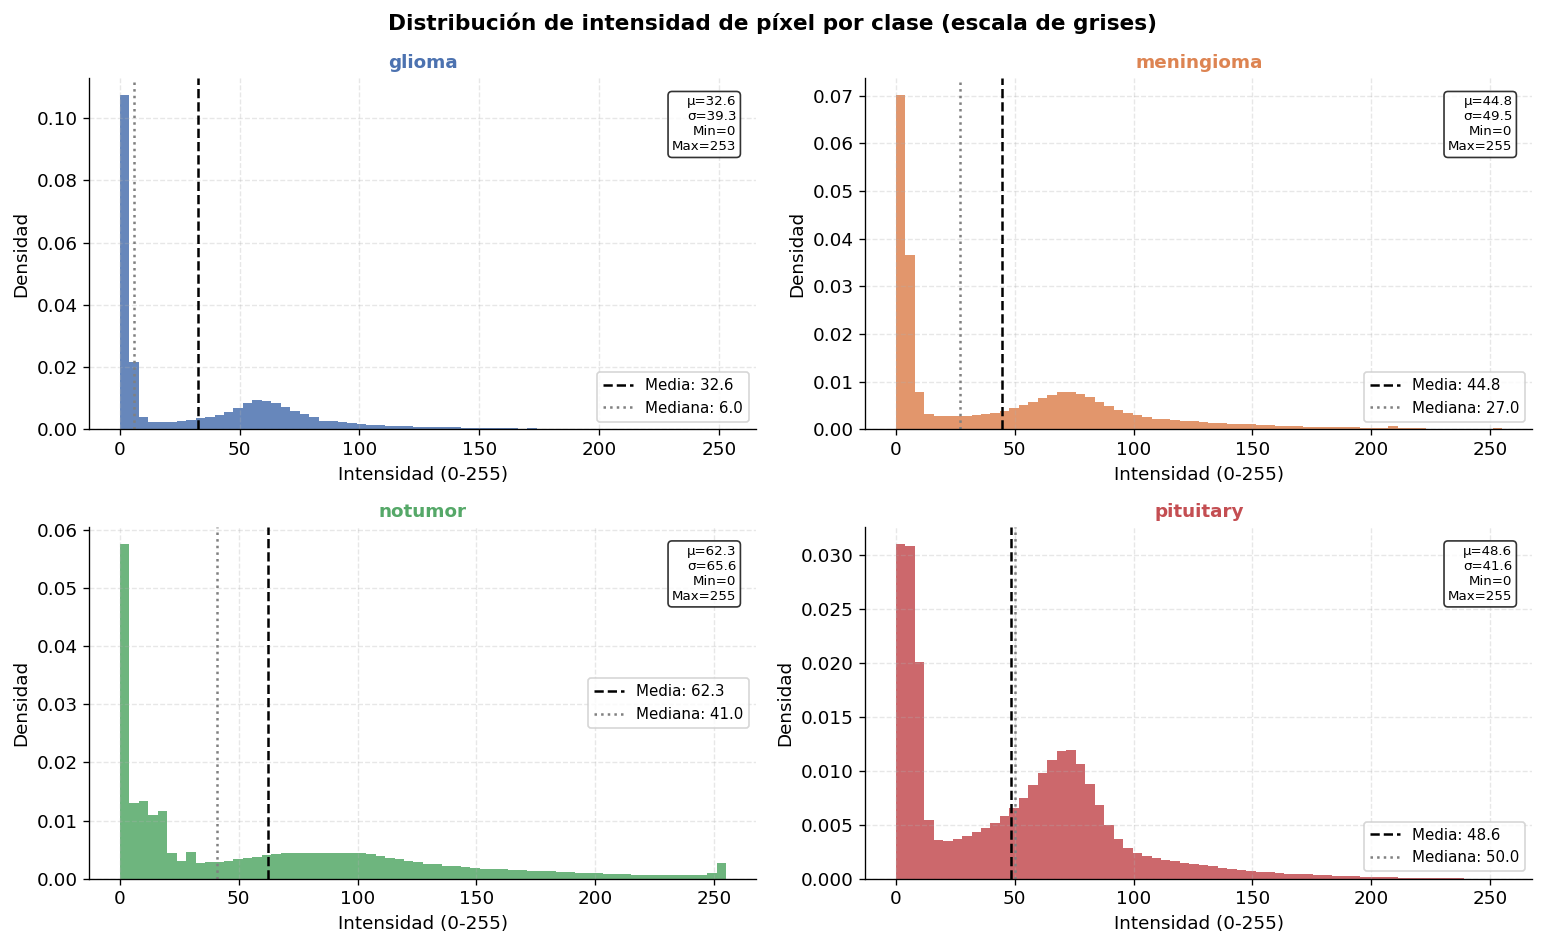

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Distribución de intensidad de píxel por clase (escala de grises)', fontsize=13, fontweight='bold')
axes = axes.flatten()

for ax, clase in zip(axes, CLASES):
    vals = np.array(pixel_vals[clase])
    ax.hist(vals, bins=64, color=PALETTE[clase], alpha=0.85, edgecolor='none', density=True)
    ax.axvline(vals.mean(), color='black', linestyle='--', linewidth=1.5, label=f'Media: {vals.mean():.1f}')
    ax.axvline(np.median(vals), color='gray',  linestyle=':',  linewidth=1.5, label=f'Mediana: {np.median(vals):.1f}')
    ax.set_title(clase, fontsize=11, fontweight='bold', color=PALETTE[clase])
    ax.set_xlabel('Intensidad (0-255)')
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3, linestyle='--')
    # Anotación de estadísticas
    textstr = f'μ={vals.mean():.1f}\nσ={vals.std():.1f}\nMin={vals.min()}\nMax={vals.max()}'
    ax.text(0.97, 0.95, textstr, transform=ax.transAxes, fontsize=8,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('eda_04_histogramas_pixeles.png', dpi=150, bbox_inches='tight')
plt.show()

Todas las clases presentan un **pico pronunciado cerca de 0** (fondo negro de la MRI)
seguido de una cola hacia la derecha (tejido cerebral e estructuras tumorales).

Diferencias relevantes entre clases:
- **glioma** (μ=32.5): distribución muy concentrada en valores bajos, tumor poco brillante
- **meningioma** (μ=44.8): perfil similar a glioma pero ligeramente más brillante
- **notumor** (μ=59.7): la más alta y con mayor dispersión (σ=64), más tejido visible
- **pituitary** (μ=50.0): distribución bimodal — fondo oscuro + estructura brillante bien definida

La similitud entre glioma y meningioma anticipa que serán las clases más difíciles
de separar tanto en ML clásico como en Deep Learning.

## 6. Estadísticas de píxel por clase: media, std, y canales RGB
Calculamos la imagen promedio por clase y la desviación estándar. Esto determina los valores de normalización para el entrenamiento.

In [17]:
# ── Media y std por canal RGB (muestra de 300 imgs por clase) ──────
SAMPLE_STATS = 300

stats = {}   # {clase: {'mean': [R,G,B], 'std': [R,G,B]}}

for clase in tqdm(CLASES, desc='Calculando estadísticas RGB'):
    folder  = os.path.join(TRAIN_DIR, clase)
    files   = random.sample(os.listdir(folder), min(SAMPLE_STATS, len(os.listdir(folder))))
    r_vals, g_vals, b_vals = [], [], []

    for fname in files:
        try:
            img = np.array(Image.open(os.path.join(folder, fname)).convert('RGB').resize(TARGET_SIZE), dtype=np.float32)
            r_vals.append(img[:, :, 0].mean())
            g_vals.append(img[:, :, 1].mean())
            b_vals.append(img[:, :, 2].mean())
        except Exception:
            pass

    stats[clase] = {
        'mean_R': np.mean(r_vals), 'std_R': np.std(r_vals),
        'mean_G': np.mean(g_vals), 'std_G': np.std(g_vals),
        'mean_B': np.mean(b_vals), 'std_B': np.std(b_vals),
    }

df_stats = pd.DataFrame(stats).T.round(2)
print('Estadísticas de píxel por clase (escala 0-255):')
print(df_stats.to_string())

Calculando estadísticas RGB:   0%|          | 0/4 [00:00<?, ?it/s]

Estadísticas de píxel por clase (escala 0-255):
               mean_R  std_R     mean_G  std_G     mean_B  std_B
glioma      32.759998   7.94  32.759998   7.94  32.759998   7.94
meningioma  43.669998  13.54  43.669998  13.54  43.669998  13.54
notumor     62.529999  20.58  62.529999  20.57  62.570000  20.57
pituitary   49.580002   8.15  49.580002   8.15  49.580002   8.15


In [18]:
# Valores de normalización globales para el entrenamiento
# Media y std sobre TODO el training set

all_means_R, all_means_G, all_means_B = [], [], []
all_stds_R,  all_stds_G,  all_stds_B  = [], [], []

for clase in CLASES:
    all_means_R.append(stats[clase]['mean_R'])
    all_means_G.append(stats[clase]['mean_G'])
    all_means_B.append(stats[clase]['mean_B'])
    all_stds_R.append(stats[clase]['std_R'])
    all_stds_G.append(stats[clase]['std_G'])
    all_stds_B.append(stats[clase]['std_B'])

global_mean = [np.mean(all_means_R)/255, np.mean(all_means_G)/255, np.mean(all_means_B)/255]
global_std  = [np.mean(all_stds_R)/255,  np.mean(all_stds_G)/255,  np.mean(all_stds_B)/255]

print('═' * 55)
print('Valores de normalización para transforms.Normalize():')
print(f'   mean = [{global_mean[0]:.4f}, {global_mean[1]:.4f}, {global_mean[2]:.4f}]')
print(f'   std  = [{global_std[0]:.4f}, {global_std[1]:.4f}, {global_std[2]:.4f}]')

═══════════════════════════════════════════════════════
Valores de normalización para transforms.Normalize():
   mean = [0.1848, 0.1848, 0.1849]
   std  = [0.0492, 0.0492, 0.0492]


Los 3 canales son prácticamente idénticos porque las MRI son escala de grises en formato RGB.

- **Modelo from scratch** → usar estos valores calculados del dataset
- **Transfer learning** → usar valores ImageNet: `mean=[0.485, 0.456, 0.406]`, `std=[0.229, 0.224, 0.225]`

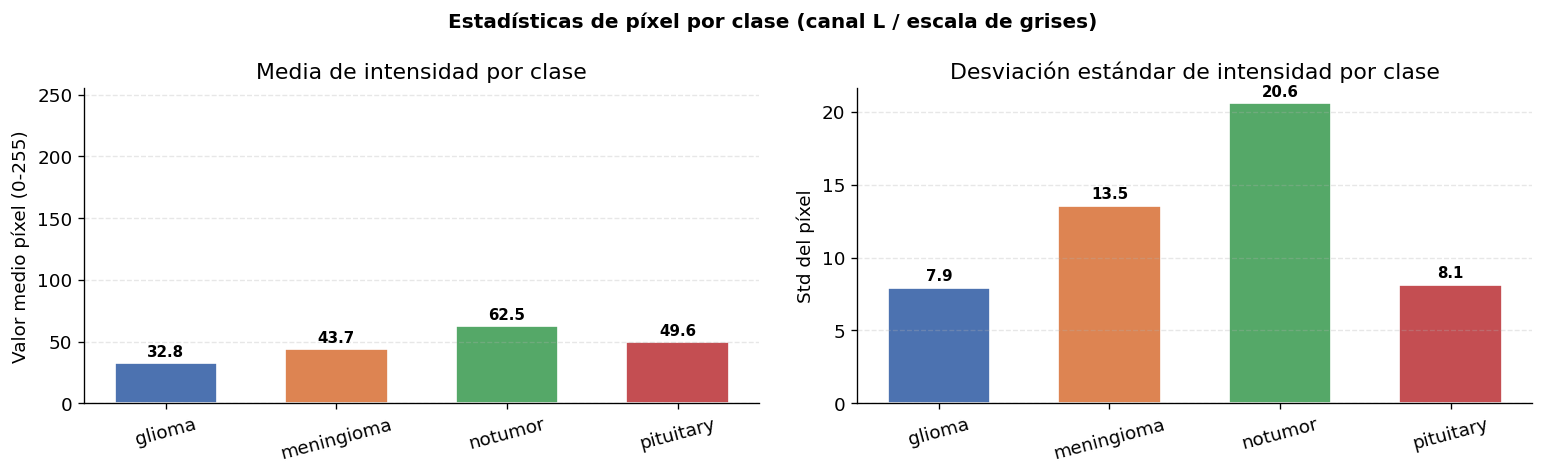

In [19]:
# Barplot de media y std por clase
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Estadísticas de píxel por clase (canal L / escala de grises)', fontsize=12, fontweight='bold')

medias = [np.mean([stats[c]['mean_R'], stats[c]['mean_G'], stats[c]['mean_B']]) for c in CLASES]
stds   = [np.mean([stats[c]['std_R'],  stats[c]['std_G'],  stats[c]['std_B']])  for c in CLASES]

axes[0].bar(CLASES, medias, color=COLORES, edgecolor='white', width=0.6)
axes[0].set_title('Media de intensidad por clase')
axes[0].set_ylabel('Valor medio píxel (0-255)')
axes[0].set_ylim(0, 255)
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
for bar, v in zip(axes[0].patches, medias):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 f'{v:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

axes[1].bar(CLASES, stds, color=COLORES, edgecolor='white', width=0.6)
axes[1].set_title('Desviación estándar de intensidad por clase')
axes[1].set_ylabel('Std del píxel')
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')
for bar, v in zip(axes[1].patches, stds):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{v:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_05_stats_pixeles.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusiones del EDA

El dataset está perfectamente balanceado (1400 train / 400 test por clase), por lo que no es necesario aplicar oversampling. Las imágenes son MRI en escala de grises, con tamaño variable especialmente en `notumor`, por lo que se aplicará resize a 224×224 antes del entrenamiento. Los histogramas de píxel revelan que todas las clases comparten un patrón similar — fondo oscuro con estructuras brillantes — siendo `glioma` y `meningioma` las más parecidas entre sí, lo que anticipa que serán las clases más difíciles de separar. Para la normalización se usarán los valores calculados del dataset (`mean=0.185, std=0.051`) en el modelo from scratch, y los valores de ImageNet (`mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]`) para transfer learning.